Feature 1462: loaded 689 rows from checkpoints\pseudotime_cells_clean_1462.pkl
Feature 1476: loaded 927 rows from checkpoints\pseudotime_cells_clean_1476.pkl
General pseudolocation summary
              n_cells  mean_width_um  median_width_um  mean_span_um  \
surface                                                               
Feature 1462      689           7.22             5.60          4.51   
Feature 1476      927           5.53             5.32          4.21   

              median_span_um  mean_profile_samples  
surface                                             
Feature 1462            4.48                 16.10  
Feature 1476            4.20                 15.04  


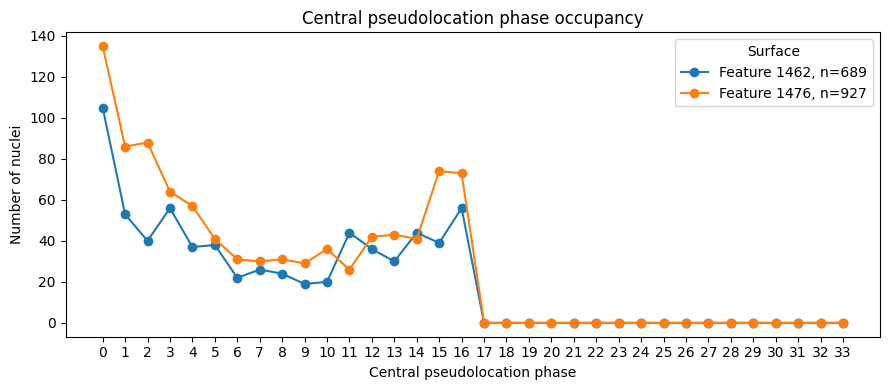

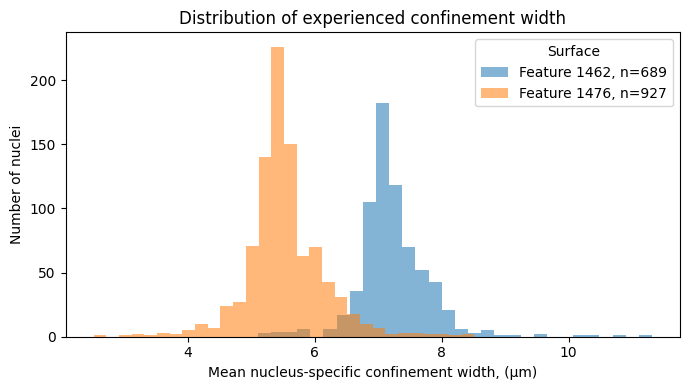

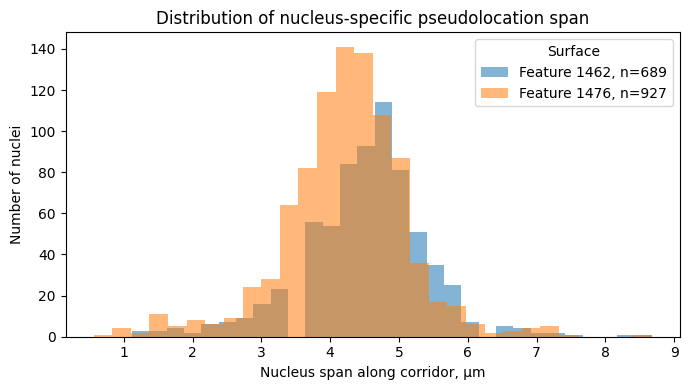

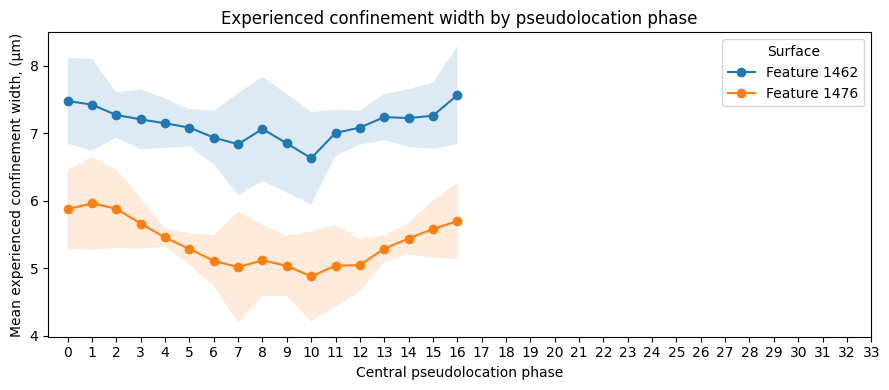

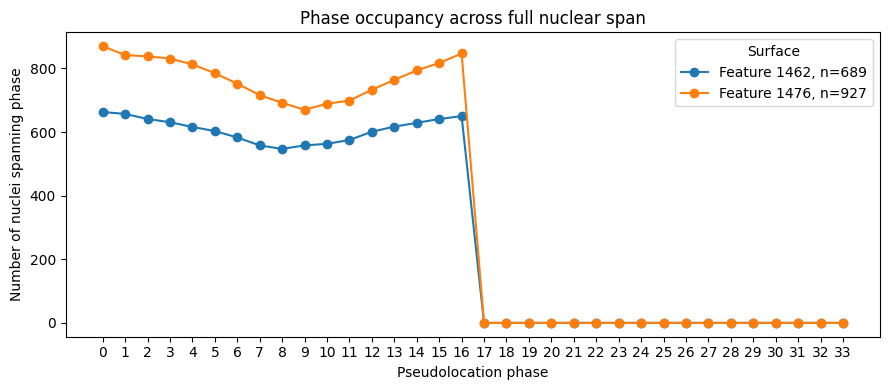

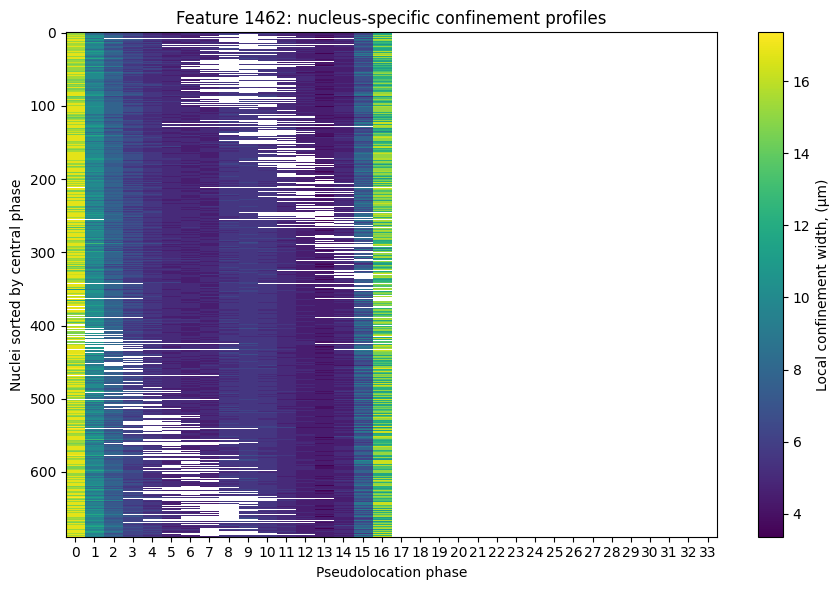

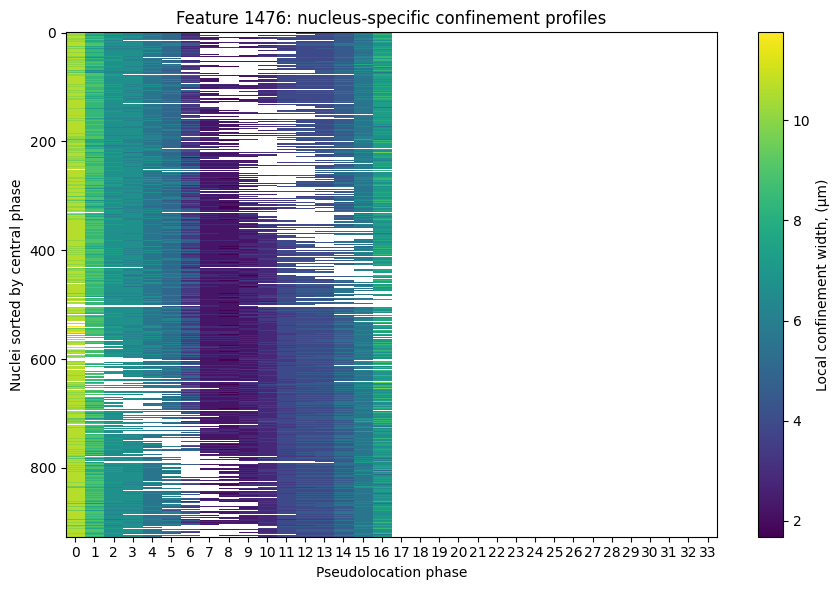

,original_index,surface,n_samples,span_um,center_phase,mean_width_um,median_width_um,min_width_um,max_width_um,std_width_um,phase_start,phase_end
0,10001,Feature 1462,18,5.04,1,7.000000,5.60,3.36,16.8,3.673351,10,10
1,20001,Feature 1462,11,3.08,16,8.145455,6.16,3.36,16.8,4.313776,12,5
2,30001,Feature 1462,18,5.04,0,7.124444,5.60,3.36,16.8,3.628281,8,8
3,40001,Feature 1462,16,4.48,3,7.385000,5.60,3.36,16.8,3.768153,13,11
4,50001,Feature 1462,14,3.92,3,7.560000,5.60,4.48,16.8,3.952721,14,10


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Input paths
# ============================================================

SURFACE_PATHS = {
    "Feature 1462": "checkpoints/pseudotime_cells_clean_1462.pkl",
    "Feature 1476": "checkpoints/pseudotime_cells_clean_1476.pkl",
}

PIXEL_SIZE_UM = 0.56
SAMPLE_STEP_PIXELS = 1
SAMPLE_STEP_UM = PIXEL_SIZE_UM * SAMPLE_STEP_PIXELS
N_BINS = 34


# ============================================================
# Helper functions
# ============================================================

def parse_array(x, dtype=float):
    """
    Convert list/array/string-stored array into a numpy array.
    Works for columns such as pseudotime and pseudotime_widths.
    """
    if isinstance(x, np.ndarray):
        return x.astype(dtype)

    if isinstance(x, list):
        return np.asarray(x, dtype=dtype)

    if isinstance(x, str):
        s = (
            x.replace("\n", " ")
             .replace(",", " ")
             .replace("[", " ")
             .replace("]", " ")
             .strip()
        )
        if s == "":
            return np.array([], dtype=dtype)
        return np.fromstring(s, sep=" ", dtype=dtype)

    if pd.isna(x):
        return np.array([], dtype=dtype)

    return np.asarray(x, dtype=dtype)


def load_surface_data(surface_paths):
    """
    Load cleaned pseudolocation datasets for multiple surfaces
    and add a surface label column.
    """
    dfs = {}

    for surface_name, path in surface_paths.items():
        path = Path(path)

        if not path.exists():
            raise FileNotFoundError(
                f"Could not find file for {surface_name}: {path.resolve()}"
            )

        df = pd.read_pickle(path)
        df = df.copy()
        df["surface"] = surface_name
        dfs[surface_name] = df

        print(f"{surface_name}: loaded {len(df)} rows from {path}")

    combined = pd.concat(dfs.values(), axis=0, ignore_index=True)

    return dfs, combined


def profile_to_phase_bins(phases, widths, n_bins=N_BINS):
    """
    Convert one nucleus-specific pseudolocation profile into a fixed-length
    vector of length n_bins.

    Each bin corresponds to one pseudolocation phase.
    If a nucleus has multiple sampled points in the same phase bin,
    their widths are averaged.
    """
    phases = parse_array(phases, dtype=int)
    widths = parse_array(widths, dtype=float)

    out = np.full(n_bins, np.nan)

    if len(phases) == 0 or len(widths) == 0 or len(phases) != len(widths):
        return out

    for b in range(n_bins):
        vals = widths[phases == b]
        if len(vals) > 0:
            out[b] = np.nanmean(vals)

    return out


def build_pseudolocation_summary(
    df,
    phase_col="pseudotime",
    width_col="pseudotime_widths",
    center_col="pseudotime_center_bin",
    n_bins=N_BINS,
    pixel_size_um=PIXEL_SIZE_UM,
    sample_step_pixels=SAMPLE_STEP_PIXELS,
    widths_are_pixels=True,
):
    """
    Build a per-cell pseudolocation summary table and a phase-width matrix.
    """

    rows = []
    valid_indices = []

    for idx, row in df.iterrows():
        phases = parse_array(row[phase_col], dtype=int)
        widths = parse_array(row[width_col], dtype=float)

        if len(phases) == 0 or len(widths) == 0 or len(phases) != len(widths):
            continue

        if widths_are_pixels:
            widths_um = widths * pixel_size_um
        else:
            widths_um = widths

        center_phase = row[center_col]

        rows.append({
            "original_index": idx,
            "surface": row.get("surface", "surface"),
            "n_samples": len(widths_um),
            "span_um": len(widths_um) * sample_step_pixels * pixel_size_um,
            "center_phase": center_phase,
            "mean_width_um": np.nanmean(widths_um),
            "median_width_um": np.nanmedian(widths_um),
            "min_width_um": np.nanmin(widths_um),
            "max_width_um": np.nanmax(widths_um),
            "std_width_um": np.nanstd(widths_um),
            "phase_start": phases[0],
            "phase_end": phases[-1],
        })

        valid_indices.append(idx)

    summary = pd.DataFrame(rows)

    phase_matrix = np.vstack([
        profile_to_phase_bins(
            df.loc[idx, phase_col],
            parse_array(df.loc[idx, width_col], dtype=float) * pixel_size_um
            if widths_are_pixels
            else df.loc[idx, width_col],
            n_bins=n_bins
        )
        for idx in valid_indices
    ])

    return summary, phase_matrix


def build_all_summaries(
    surface_dfs,
    phase_col="pseudotime",
    width_col="pseudotime_widths",
    center_col="pseudotime_center_bin",
    n_bins=N_BINS,
    pixel_size_um=PIXEL_SIZE_UM,
    sample_step_pixels=SAMPLE_STEP_PIXELS,
    widths_are_pixels=True,
):
    """
    Build summaries and matrices for all surfaces.
    """
    summaries = {}
    matrices = {}

    for surface_name, df in surface_dfs.items():
        summary, matrix = build_pseudolocation_summary(
            df=df,
            phase_col=phase_col,
            width_col=width_col,
            center_col=center_col,
            n_bins=n_bins,
            pixel_size_um=pixel_size_um,
            sample_step_pixels=sample_step_pixels,
            widths_are_pixels=widths_are_pixels,
        )

        summaries[surface_name] = summary
        matrices[surface_name] = matrix

    combined_summary = pd.concat(summaries.values(), axis=0, ignore_index=True)

    return summaries, matrices, combined_summary


# ============================================================
# Comparative plotting functions
# ============================================================

def plot_general_dataset_summary(combined_summary):
    """
    Print general pseudolocation incorporation summary for both surfaces.
    """
    print("============================================")
    print("General pseudolocation summary")
    print("============================================")

    overview = (
        combined_summary
        .groupby("surface")
        .agg(
            n_cells=("mean_width_um", "size"),
            mean_width_um=("mean_width_um", "mean"),
            median_width_um=("median_width_um", "median"),
            mean_span_um=("span_um", "mean"),
            median_span_um=("span_um", "median"),
            mean_profile_samples=("n_samples", "mean"),
        )
        .round(2)
    )

    print(overview)
    return overview


def plot_central_phase_occupancy(
    combined_summary,
    n_bins=N_BINS,
    save_path=None,
):
    """
    Compare central pseudolocation phase occupancy between surfaces.
    """
    plt.figure(figsize=(9, 4))

    for surface_name, group in combined_summary.groupby("surface"):
        center_values = (
            pd.to_numeric(group["center_phase"], errors="coerce")
            .dropna()
            .astype(int)
        )

        counts = np.zeros(n_bins, dtype=int)

        for b in center_values:
            if 0 <= b < n_bins:
                counts[b] += 1

        plt.plot(
            np.arange(n_bins),
            counts,
            marker="o",
            label=f"{surface_name}, n={len(group)}"
        )

    plt.xlabel("Central pseudolocation phase")
    plt.ylabel("Number of nuclei")
    plt.title("Central pseudolocation phase occupancy")
    plt.xticks(np.arange(n_bins))
    plt.legend(title="Surface")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()


def plot_mean_width_distribution(
    combined_summary,
    bins=30,
    save_path=None,
):
    """
    Compare distributions of mean nucleus-specific confinement width.
    """
    plt.figure(figsize=(7, 4))

    for surface_name, group in combined_summary.groupby("surface"):
        plt.hist(
            group["mean_width_um"].dropna(),
            bins=bins,
            alpha=0.55,
            label=f"{surface_name}, n={len(group)}"
        )

    plt.xlabel("Mean nucleus-specific confinement width, (µm)")
    plt.ylabel("Number of nuclei")
    plt.title("Distribution of experienced confinement width")
    plt.legend(title="Surface")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()


def plot_span_distribution(
    combined_summary,
    bins=30,
    save_path=None,
):
    """
    Compare distributions of nucleus span along the corridor.
    """
    plt.figure(figsize=(7, 4))

    for surface_name, group in combined_summary.groupby("surface"):
        plt.hist(
            group["span_um"].dropna(),
            bins=bins,
            alpha=0.55,
            label=f"{surface_name}, n={len(group)}"
        )

    plt.xlabel("Nucleus span along corridor, µm")
    plt.ylabel("Number of nuclei")
    plt.title("Distribution of nucleus-specific pseudolocation span")
    plt.legend(title="Surface")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()


def plot_width_by_phase(
    combined_summary,
    n_bins=N_BINS,
    save_path=None,
):
    """
    Compare mean experienced confinement width by central pseudolocation phase.
    """
    plt.figure(figsize=(9, 4))

    for surface_name, group in combined_summary.groupby("surface"):
        phase_stats = (
            group
            .dropna(subset=["center_phase", "mean_width_um"])
            .assign(center_phase=lambda x: x["center_phase"].astype(int))
            .groupby("center_phase")
            .agg(
                n=("mean_width_um", "size"),
                mean_width_um=("mean_width_um", "mean"),
                std_width_um=("mean_width_um", "std"),
            )
            .reindex(np.arange(n_bins))
        )

        x = np.arange(n_bins)
        y = phase_stats["mean_width_um"].to_numpy()
        yerr = phase_stats["std_width_um"].to_numpy()

        plt.plot(
            x,
            y,
            marker="o",
            label=f"{surface_name}"
        )

        plt.fill_between(
            x,
            y - yerr,
            y + yerr,
            alpha=0.15
        )

    plt.xlabel("Central pseudolocation phase")
    plt.ylabel("Mean experienced confinement width, (µm)")
    plt.title("Experienced confinement width by pseudolocation phase")
    plt.xticks(np.arange(n_bins))
    plt.legend(title="Surface")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()


def plot_full_span_phase_occupancy(
    matrices,
    n_bins=N_BINS,
    save_path=None,
):
    """
    Compare how often each pseudolocation phase is spanned by nuclei.
    This uses the full nucleus-specific profile, not only the center phase.
    """
    plt.figure(figsize=(9, 4))

    for surface_name, matrix in matrices.items():
        phase_occupancy = np.sum(np.isfinite(matrix), axis=0)

        plt.plot(
            np.arange(n_bins),
            phase_occupancy,
            marker="o",
            label=f"{surface_name}, n={matrix.shape[0]}"
        )

    plt.xlabel("Pseudolocation phase")
    plt.ylabel("Number of nuclei spanning phase")
    plt.title("Phase occupancy across full nuclear span")
    plt.xticks(np.arange(n_bins))
    plt.legend(title="Surface")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()


def plot_profile_heatmaps(
    summaries,
    matrices,
    n_bins=N_BINS,
    save_prefix=None,
):
    """
    Plot nucleus-specific confinement profile heatmaps separately for each surface.
    These are separated because heatmaps are easier to read per surface.
    """
    for surface_name in summaries.keys():
        summary = summaries[surface_name]
        matrix = matrices[surface_name]

        order = np.argsort(
            pd.to_numeric(summary["center_phase"], errors="coerce")
            .fillna(-1)
            .to_numpy()
        )

        matrix_sorted = matrix[order, :]

        plt.figure(figsize=(9, 6))
        plt.imshow(
            matrix_sorted,
            aspect="auto",
            interpolation="nearest"
        )
        plt.colorbar(label="Local confinement width, (µm)")
        plt.xlabel("Pseudolocation phase")
        plt.ylabel("Nuclei sorted by central phase")
        plt.title(f"{surface_name}: nucleus-specific confinement profiles")
        plt.xticks(np.arange(n_bins))
        plt.tight_layout()

        if save_prefix is not None:
            safe_name = surface_name.replace(" ", "_").lower()
            plt.savefig(f"{save_prefix}_{safe_name}_profile_heatmap.png", dpi=300)

        plt.show()


def plot_all_surface_comparison(
    combined_summary,
    summaries,
    matrices,
    n_bins=N_BINS,
    save_prefix=None,
):
    """
    Run all general comparative plots for both surfaces.
    """

    overview = plot_general_dataset_summary(combined_summary)

    plot_central_phase_occupancy(
        combined_summary,
        n_bins=n_bins,
        save_path=f"{save_prefix}_central_phase_occupancy.png" if save_prefix else None,
    )

    plot_mean_width_distribution(
        combined_summary,
        save_path=f"{save_prefix}_mean_width_distribution.png" if save_prefix else None,
    )

    plot_span_distribution(
        combined_summary,
        save_path=f"{save_prefix}_span_distribution.png" if save_prefix else None,
    )

    plot_width_by_phase(
        combined_summary,
        n_bins=n_bins,
        save_path=f"{save_prefix}_width_by_phase.png" if save_prefix else None,
    )

    plot_full_span_phase_occupancy(
        matrices,
        n_bins=n_bins,
        save_path=f"{save_prefix}_full_span_phase_occupancy.png" if save_prefix else None,
    )

    plot_profile_heatmaps(
        summaries,
        matrices,
        n_bins=n_bins,
        save_prefix=save_prefix,
    )

    return overview


# ============================================================
# Run analysis
# ============================================================

surface_dfs, combined_df = load_surface_data(SURFACE_PATHS)

summaries, matrices, combined_summary = build_all_summaries(
    surface_dfs,
    phase_col="pseudotime",
    width_col="pseudotime_widths",
    center_col="pseudotime_center_bin",
    n_bins=N_BINS,
    pixel_size_um=PIXEL_SIZE_UM,
    sample_step_pixels=SAMPLE_STEP_PIXELS,
    widths_are_pixels=True,
)

overview = plot_all_surface_comparison(
    combined_summary=combined_summary,
    summaries=summaries,
    matrices=matrices,
    n_bins=N_BINS,
    save_prefix=None,
)

combined_summary.head()

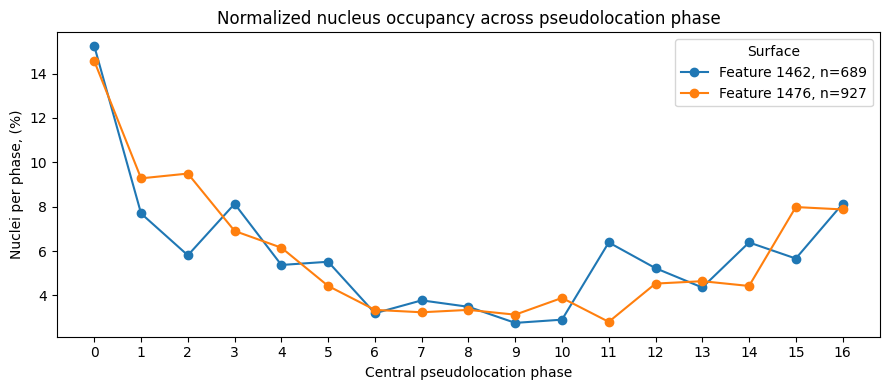

In [3]:
def plot_n_per_phase_normalized(combined_summary, n_bins=17):
    plt.figure(figsize=(9, 4))

    for surface_name, group in combined_summary.groupby("surface"):
        center_values = (
            pd.to_numeric(group["center_phase"], errors="coerce")
            .dropna()
            .astype(int)
        )

        counts = np.zeros(n_bins, dtype=int)

        for b in center_values:
            if 0 <= b < n_bins:
                counts[b] += 1

        percentages = counts / counts.sum() * 100

        plt.plot(
            np.arange(n_bins),
            percentages,
            marker="o",
            label=f"{surface_name}, n={counts.sum()}"
        )

    plt.xlabel("Central pseudolocation phase")
    plt.ylabel("Nuclei per phase, (%)")
    plt.title("Normalized nucleus occupancy across pseudolocation phase")
    plt.xticks(np.arange(n_bins))
    plt.legend(title="Surface")
    plt.tight_layout()
    plt.show()


plot_n_per_phase_normalized(combined_summary, n_bins=17)

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd


# ============================================================
# Input paths
# ============================================================

SURFACE_PATHS = {
    "Feature 1462": "checkpoints/pseudotime_cells_clean_1462.pkl",
    "Feature 1476": "checkpoints/pseudotime_cells_clean_1476.pkl",
}

OUTLIER_PATHS = {
    "Feature 1462": "datasets/1462_dapi_python_segmentation_outliers.txt",
    "Feature 1476": "datasets/1476_dapi_python_segmentation_outliers.txt",
}

MIN_PROFILE_LENGTH = 6


# ============================================================
# Helper functions
# ============================================================

def parse_array(x, dtype=float):
    """
    Robustly convert pseudotime / pseudotime_widths values to numpy arrays.
    This prevents len() from accidentally counting characters if arrays
    are stored as strings.
    """
    if isinstance(x, np.ndarray):
        return x.astype(dtype)

    if isinstance(x, list):
        return np.asarray(x, dtype=dtype)

    if isinstance(x, str):
        s = (
            x.replace("\n", " ")
             .replace(",", " ")
             .replace("[", " ")
             .replace("]", " ")
             .strip()
        )
        if s == "":
            return np.array([], dtype=dtype)
        return np.fromstring(s, sep=" ", dtype=dtype)

    if pd.isna(x):
        return np.array([], dtype=dtype)

    return np.asarray(x, dtype=dtype)


def get_profile_length(x):
    return len(parse_array(x, dtype=float))


def load_outlier_names(outlier_path):
    """
    Reads outlier names from txt file.

    If lines contain names without .tif, .tif is added.
    If lines already contain .tif, they are kept.
    """
    outlier_path = Path(outlier_path)

    if not outlier_path.exists():
        print(f"No outlier file found: {outlier_path}")
        return set()

    outliers = []

    with open(outlier_path, "r") as f:
        for line in f:
            name = line.strip()

            if name == "":
                continue

            if not name.lower().endswith(".tif"):
                name = name + ".tif"

            outliers.append(name)

    return set(outliers)


def filter_surface_dataframe(
    df,
    surface_name,
    outlier_path=None,
    min_profile_length=6,
    path_col="path_dapi",
    width_col="pseudotime_widths",
):
    """
    Applies:
    1. minimum pseudolocation profile length filter
    2. DAPI segmentation outlier removal
    """

    df = df.copy()

    n_start = len(df)

    # --------------------------------------------------------
    # Filter by minimum pseudolocation profile length
    # --------------------------------------------------------
    df["_profile_length"] = df[width_col].apply(get_profile_length)

    df = df[df["_profile_length"] >= min_profile_length].copy()

    n_after_length = len(df)

    # --------------------------------------------------------
    # Remove segmentation outliers
    # --------------------------------------------------------
    n_outlier_file = 0

    if outlier_path is not None:
        outlier_names = load_outlier_names(outlier_path)
        n_outlier_file = len(outlier_names)

        if len(outlier_names) > 0:
            df = df[
                ~df[path_col]
                .apply(lambda p: Path(str(p)).name)
                .isin(outlier_names)
            ].copy()

    n_final = len(df)

    df["surface"] = surface_name

    print("--------------------------------------------------")
    print(surface_name)
    print("--------------------------------------------------")
    print(f"Initial nuclei:                         {n_start}")
    print(f"After profile length >= {min_profile_length}:       {n_after_length}")
    print(f"Outlier names loaded from file:          {n_outlier_file}")
    print(f"Final nuclei after outlier removal:      {n_final}")
    print(f"Removed total:                           {n_start - n_final}")
    print(f"Retention:                               {n_final / n_start * 100:.2f}%")
    print()

    return df


def load_filtered_surface_data(
    surface_paths,
    outlier_paths=None,
    min_profile_length=6,
):
    """
    Loads and filters all surfaces.
    """

    surface_dfs = {}

    for surface_name, pkl_path in surface_paths.items():
        df = pd.read_pickle(pkl_path)

        outlier_path = None
        if outlier_paths is not None:
            outlier_path = outlier_paths.get(surface_name, None)

        df_filtered = filter_surface_dataframe(
            df=df,
            surface_name=surface_name,
            outlier_path=outlier_path,
            min_profile_length=min_profile_length,
        )

        surface_dfs[surface_name] = df_filtered

    combined_df = pd.concat(
        surface_dfs.values(),
        axis=0,
        ignore_index=True
    )

    return surface_dfs, combined_df

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_combined_pseudolocation_summary(
    combined_summary,
    n_bins=17,
    deviation="std",  # "std" or "sem"
    surface_col="surface",
    phase_col="center_phase",
    width_col="mean_width_um",
    save_path=None,
    dpi=300,
):
    """
    Combined manuscript-style plot:
    A) normalized nucleus occupancy across pseudolocation phase
    B) experienced confinement width by pseudolocation phase

    Requires combined_summary with columns:
    - surface
    - center_phase
    - mean_width_um
    """

    df = combined_summary.copy()

    df[phase_col] = pd.to_numeric(df[phase_col], errors="coerce")
    df[width_col] = pd.to_numeric(df[width_col], errors="coerce")

    df = df.dropna(subset=[surface_col, phase_col, width_col])
    df[phase_col] = df[phase_col].astype(int)

    surfaces = list(df[surface_col].dropna().unique())
    x = np.arange(n_bins)

    if deviation.lower() == "sem":
        dev_label = "SEM"
    elif deviation.lower() == "std":
        dev_label = "SD"
    else:
        raise ValueError("deviation must be either 'std' or 'sem'")

    fig, (ax_occ, ax_width) = plt.subplots(
        2,
        1,
        figsize=(7.2, 5.0),
        sharex=True,
        gridspec_kw={
            "height_ratios": [1.0, 1.45],
            "hspace": 0.08,
        },
    )

    legend_handles = []
    legend_labels = []

    for surface_name in surfaces:
        group = df[df[surface_col] == surface_name].copy()

        # ----------------------------------------------------
        # A. Occupancy per central phase
        # ----------------------------------------------------
        counts = np.zeros(n_bins, dtype=int)

        for phase in group[phase_col]:
            if 0 <= phase < n_bins:
                counts[phase] += 1

        total = counts.sum()

        if total == 0:
            continue

        percentages = counts / total * 100

        line_occ, = ax_occ.plot(
            x,
            percentages,
            marker="o",
            markersize=4.5,
            linewidth=1.8,
            label=f"{surface_name}, n={total}",
        )

        color = line_occ.get_color()

        legend_handles.append(line_occ)
        legend_labels.append(f"{surface_name}, n={total}")

        # ----------------------------------------------------
        # B. Width statistics per central phase
        # ----------------------------------------------------
        phase_stats = (
            group
            .groupby(phase_col)
            .agg(
                n=(width_col, "size"),
                mean_width=(width_col, "mean"),
                std_width=(width_col, "std"),
            )
            .reindex(x)
        )

        mean = phase_stats["mean_width"].to_numpy(dtype=float)
        std = phase_stats["std_width"].to_numpy(dtype=float)
        n = phase_stats["n"].to_numpy(dtype=float)

        if deviation.lower() == "sem":
            dev = std / np.sqrt(n)
        else:
            dev = std

        lower = mean - dev
        upper = mean + dev

        ax_width.plot(
            x,
            mean,
            marker="o",
            markersize=4.5,
            linewidth=1.8,
            color=color,
        )

        ax_width.fill_between(
            x,
            lower,
            upper,
            color=color,
            alpha=0.18,
            linewidth=0,
        )

        ax_width.plot(
            x,
            lower,
            linestyle="--",
            linewidth=0.9,
            color=color,
            alpha=0.75,
        )

        ax_width.plot(
            x,
            upper,
            linestyle="--",
            linewidth=0.9,
            color=color,
            alpha=0.75,
        )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------
    ax_occ.set_ylabel("Nuclei per phase, (%)")
    ax_width.set_ylabel(f"Mean confinement\nwidth, (µm ± {dev_label})")
    ax_width.set_xlabel("Central pseudolocation phase")

    ax_width.set_xticks(x)
    ax_width.set_xlim(-0.4, n_bins - 0.6)

    ax_occ.tick_params(axis="x", labelbottom=False)

    # Panel labels
    ax_occ.text(
        -0.08,
        1.05,
        "A",
        transform=ax_occ.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
    )

    ax_width.text(
        -0.08,
        1.05,
        "B",
        transform=ax_width.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
    )

    # Styling
    for ax in [ax_occ, ax_width]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.25)
        ax.tick_params(axis="both", labelsize=9)

    ax_occ.legend(
        handles=legend_handles,
        labels=legend_labels,
        title="Surface",
        frameon=False,
        fontsize=8.5,
        title_fontsize=9,
        loc="upper right",
    )

    fig.align_ylabels([ax_occ, ax_width])
    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        top=0.97,
        bottom=0.11,
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

    return fig, (ax_occ, ax_width)

--------------------------------------------------
Feature 1462
--------------------------------------------------
Initial nuclei:                         689
After profile length >= 6:       683
Outlier names loaded from file:          45
Final nuclei after outlier removal:      656
Removed total:                           33
Retention:                               95.21%

--------------------------------------------------
Feature 1476
--------------------------------------------------
Initial nuclei:                         927
After profile length >= 6:       909
Outlier names loaded from file:          54
Final nuclei after outlier removal:      878
Removed total:                           49
Retention:                               94.71%



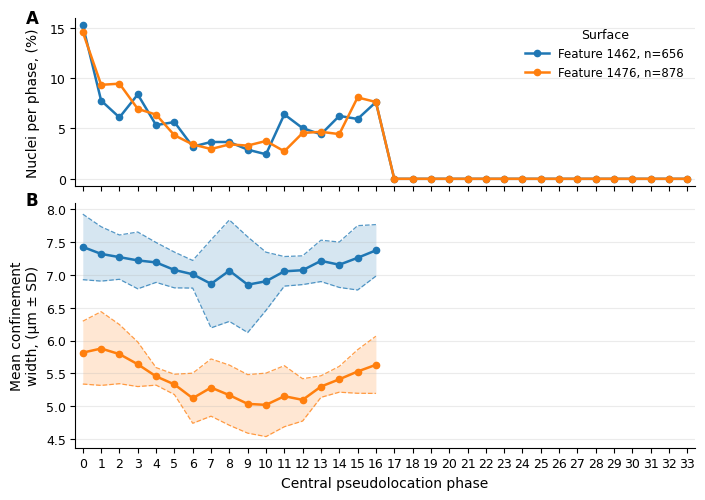

(<Figure size 720x500 with 2 Axes>,
 (<Axes: ylabel='Nuclei per phase, (%)'>,
  <Axes: xlabel='Central pseudolocation phase', ylabel='Mean confinement\nwidth, (µm ± SD)'>))

In [11]:
surface_dfs, combined_df = load_filtered_surface_data(
    surface_paths=SURFACE_PATHS,
    outlier_paths=OUTLIER_PATHS,
    min_profile_length=MIN_PROFILE_LENGTH,
)
summaries, matrices, combined_summary = build_all_summaries(
    surface_dfs,
    phase_col="pseudotime",
    width_col="pseudotime_widths",
    center_col="pseudotime_center_bin",
    n_bins=34,
    pixel_size_um=0.56,
    sample_step_pixels=1,
    widths_are_pixels=True,
)
plot_combined_pseudolocation_summary(
    combined_summary,
    n_bins=34,
    deviation="std",
    save_path="combined_pseudolocation_summary_filtered.pdf"
)

In [12]:
for surface_name, df in surface_dfs.items():
    print("\n", surface_name)

    centers = pd.to_numeric(df["pseudotime_center_bin"], errors="coerce").dropna()
    print("center min:", centers.min())
    print("center max:", centers.max())
    print("center unique:", sorted(centers.astype(int).unique()))

    all_phases = []
    for x in df["pseudotime"]:
        arr = parse_array(x, dtype=int)
        if len(arr) > 0:
            all_phases.append(arr)

    all_phases = np.concatenate(all_phases)
    print("pseudotime min:", all_phases.min())
    print("pseudotime max:", all_phases.max())
    print("pseudotime unique:", sorted(np.unique(all_phases)))


 Feature 1462
center min: 0
center max: 16
center unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
pseudotime min: 0
pseudotime max: 16
pseudotime unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]

 Feature 1476
center min: 0
center max: 16
center unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
pseudotime min: 0
pseudotime max: 16
pseudotime unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.i